In [6]:
import numpy as np
import treecorr
from astropy.io import fits
import fitsio
import numpy as np
import Corrfunc
from Corrfunc.mocks.DDtheta_mocks import DDtheta_mocks
from Corrfunc.io import read_catalog
from Corrfunc.utils import convert_3d_counts_to_cf
from astropy.table import Table, join
from astropy.coordinates import SkyCoord

from multiprocessing import Pool
import pyarrow.parquet as pq
from multiprocessing import Pool, cpu_count
import pyarrow as pa
import matplotlib.pyplot as plt
import scienceplots
import argparse
import multiprocessing
import sys
import healpy as hp
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
import scienceplots
plt.style.use(['science', 'notebook', 'grid'])

In [ ]:
randoms_huge= Table.read('/user/animesh.sah/FP_CUTS/randoms_with_mags.fits')

In [7]:
randoms = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/randoms_5M.fits')[1].read())
randoms = randoms[randoms['DEC']>-30]

In [8]:
randoms_north = randoms[randoms['PHOTSYS'] == 'N']
randoms_south = randoms[randoms['PHOTSYS'] == 'S']


In [9]:
def coords_to_pix(ra_deg, dec_deg, nside,**kwargs):
    theta = np.radians(90.0 - dec_deg)  
    phi   = np.radians(ra_deg)
    ipix  = hp.ang2pix(nside, theta, phi,**kwargs)
    return ipix

In [10]:
map = np.zeros(hp.nside2npix(1024), dtype=np.int32)

In [15]:
hpx_north = coords_to_pix(randoms_north['RA'], randoms_north['DEC'], nside=1024)
hpx_south = coords_to_pix(randoms_south['RA'], randoms_south['DEC'], nside=1024)
map_north = np.bincount(hpx_north, minlength=hp.nside2npix(1024))
map_south = np.bincount(hpx_south, minlength=hp.nside2npix(1024))

In [5]:
hp.mollview(map_north, title='North Map', cmap='magma_r')
hp.graticule()
hp.mollview(map_south, title='South Map', cmap='magma_r')
hp.graticule()


NameError: name 'map_north' is not defined

In [9]:
area_north

NameError: name 'area_north' is not defined

In [8]:
def compute_magnitudes( legacy):
        """Compute magnitudes and color indices from flux measurements"""
        print("Computing magnitudes and colors...")
        
        MAG = {}
        MAG_NOEXT = {}
        
        for band in ['G', 'R', 'Z', 'W1', 'W2', 'W3']:
            flux = np.array(legacy[f'FLUX_{band}'])
            trans = np.array(legacy[f'MW_TRANSMISSION_{band}'])
            frac = flux / trans
            valid = (frac > 0) & np.isfinite(frac)

            mag = np.full_like(frac, fill_value=np.nan)
            mag_noext = np.full_like(frac, fill_value=np.nan)
            
            # Handle zero/negative fluxes
            
            np.log10(flux, out=mag_noext, where=valid)
            np.log10(frac, out=mag, where=valid)

            MAG[band] = 22.5 - 2.5 * mag
            MAG_NOEXT[band] = 22.5 - 2.5 * mag_noext
            
            legacy[f'MAG_{band}'] = MAG[band]

        # Compute color indices

        color_combinations = [
            ('G', 'R'), ('R', 'Z'), ('G', 'Z'),
            ('W1', 'W2'), ('W2', 'W3'), ('W1', 'W3'),
            ('R', 'W1'), ('R', 'W2'), ('R', 'W3'),
            ('G', 'W1'), ('G', 'W2'), ('G', 'W3'),
            ('Z', 'W1'), ('Z', 'W2'), ('Z', 'W3')
        ]
        
        for band1, band2 in color_combinations:
            legacy[f'MAG_{band1}{band2}'] = legacy[f'MAG_{band1}'] - legacy[f'MAG_{band2}']
        #legacy = self._add_features(legacy)
        
        return legacy


def _add_features( legacy):
    """Add additional features to the dataset"""
    e1,e2 = legacy['SHAPE_E1'], legacy['SHAPE_E2']
    epsilon = np.sqrt(e1**2 + e2**2)
    bba = (1 - epsilon) / (1 + epsilon)
    r_circ = np.sqrt(bba) * legacy['SHAPE_R']
    legacy['BBA'] = bba
    legacy['R_CIRC'] = r_circ
    return legacy



In [16]:
area_north = np.sum(map_north > 0) * hp.nside2pixarea(1024, degrees=True)
area_south = np.sum(map_south > 0) * hp.nside2pixarea(1024, degrees=True)

In [10]:
data_south = Table.read('/user/animesh.sah/FP_CUTS/table_south_unique.fits')
data_north = Table.read('/user/animesh.sah/FP_CUTS/table_north_unique.fits')

In [11]:
DR1_north= Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/TABLE_DR1_north_v1_sep_1.fits')[1].read())
DR1_south= Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/TABLE_DR1_south_v1_sep_1.fits')[1].read())
legacy_north = Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/TABLE_legacy_north_v1_sep_1.fits')[1].read())
legacy_south = Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/TABLE_legacy_south_v1_sep_1.fits')[1].read())
legacy_south['Z_DR1'] = DR1_south['Z']
legacy_north['Z_DR1'] = DR1_north['Z']
legacy_north = compute_magnitudes(legacy_north)
legacy_south = compute_magnitudes(legacy_south)
legacy_north = _add_features(legacy_north)
legacy_south = _add_features(legacy_south)

Computing magnitudes and colors...
Computing magnitudes and colors...


In [21]:

data_DR1_south = join(legacy_south, data_south, keys=['BRICKID', 'BRICKNAME', 'OBJID'], join_type='inner')
data_DR1_north = join(legacy_north, data_north, keys=['BRICKID', 'BRICKNAME', 'OBJID'], join_type='inner')

In [23]:
plt.hist(data_DR1_south['MAG_R'],bins = 50, alpha=0.8, label='South (DR1)',edgecolor='w',density=True)
plt.hist(data_DR1_north['MAG_R'],bins = 50, alpha=0.3, label='North (DR1)',edgecolor='w',density=True,color='r')
plt.xlabel('MAG_R')
plt.ylabel('Count')
plt.title('Distribution of MAG_R for South and North')
plt.legend()
plt.show()

KeyError: 'MAG_R'

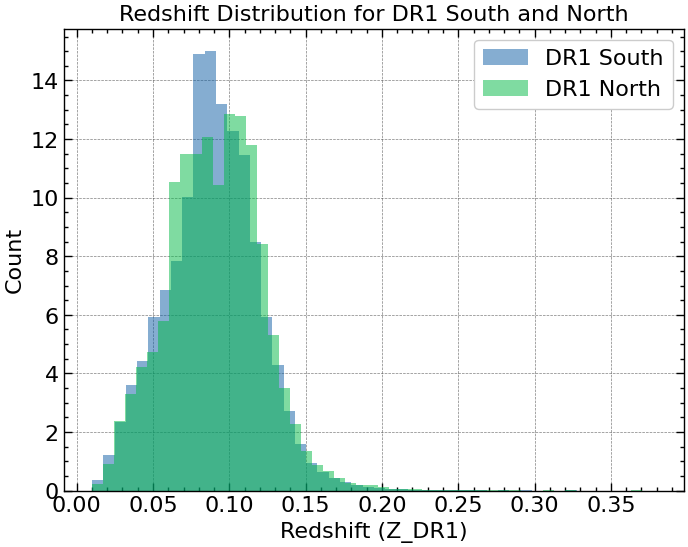

In [ ]:
plt.hist(data_DR1_south['Z_DR1'], bins=50, alpha=0.5, label='DR1 South',density=True)
plt.hist(data_DR1_north['Z_DR1'], bins=50, alpha=0.5, label='DR1 North',density=True)
plt.xlabel('Redshift (Z_DR1)')
plt.ylabel('Count')
plt.title('Redshift Distribution for DR1 South and North')
plt.legend()
plt.show()

In [20]:
plt.hist(data_DR1_south_subset['Z_DR1'], bins=50, alpha=0.5, label='DR1 South')
plt.hist(data_DR1_north_subset['Z_DR1'], bins=50, alpha=0.5, label='DR1 North')
plt.xlabel('Redshift (Z_DR1)')
plt.ylabel('Count')
plt.title('Redshift Distribution for DR1 South and North')
plt.legend()
plt.show()

NameError: name 'data_DR1_south_subset' is not defined

In [19]:
data_DR1_south_subset = data_DR1_south[data_DR1_south['Z_DR1'] < 0.15]
data_DR1_north_subset = data_DR1_north[data_DR1_north['Z_DR1'] < 0.15]

plt.hist(data_DR1_south_subset['MAG_R'],bins = 50, alpha=0.8, label='South (DR1)',edgecolor='w',density=True)
plt.hist(data_DR1_north_subset['MAG_R'],bins = 50, alpha=0.3, label='North (DR1)',edgecolor='w',density=True,color='r')
plt.xlabel('MAG_R')
plt.ylabel('Count')
plt.title('Distribution of MAG_R for South and North')
plt.legend()
plt.show()

NameError: name 'data_DR1_south' is not defined

In [18]:
 def apply_cuts_phot(table):
    cut1 = (table['MAG_R'] < 18)

    cut2 = cut1 & ((table['MAG_G'] - table['MAG_R']) > 0.68)


    cut3 = cut2 & ((table['MAG_G'] - table['MAG_R']) > (1.3 * (table['MAG_R'] - table['MAG_Z']) - 0.05))

    cut4 = cut3 & ((table['MAG_G'] - table['MAG_R']) < (2.0 * (table['MAG_R'] - table['MAG_Z']) - 0.15))


    cut5 = cut4 & (table['R_CIRC'] > 0)

    cut6 = cut5 & ((1 - table['BBA']) < 0.7)
    cut7 = cut6 & (((table['TYPE'] == 'SER') & (table['SERSIC'] > 2.5)) | (table['TYPE'] == 'DEV'))
    return cut1 & cut2 & cut3 & cut4 & cut5 & cut6 & cut7


def apply_cuts_spec(table,zcut=0.15):
    cut1 = (table['Z_DR1'] < zcut)
    return cut1


In [ ]:
apply_cuts_phot(legacy_south)
legacy_south_phot_masked =legacy_south[apply_cuts_phot(legacy_south)]    
legacy_north_phot_masked =legacy_north[apply_cuts_phot(legacy_north)]

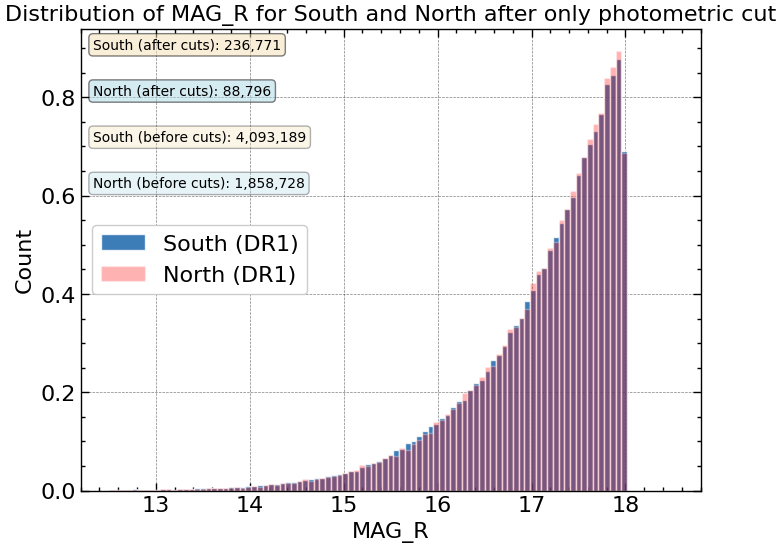

In [ ]:
legacy_south_phot_masked =legacy_south[apply_cuts_phot(legacy_south)]    
bins  = np.linspace(12.5,18.5,100)
plt.hist(legacy_south_phot_masked['MAG_R'],bins = bins, alpha=0.8, label='South (DR1)',edgecolor='w',density=True)
plt.hist(legacy_north_phot_masked['MAG_R'],bins = bins, alpha=0.3, label='North (DR1)',edgecolor='w',density=True,color='r')  
# Add text boxes with number of elements before and after cuts
plt.text(0.02, 0.98, f'South (after cuts): {len(legacy_south_phot_masked):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(0.02, 0.88, f'North (after cuts): {len(legacy_north_phot_masked):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
plt.text(0.02, 0.78, f'South (before cuts): {len(legacy_south):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
plt.text(0.02, 0.68, f'North (before cuts): {len(legacy_north):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
plt.xlabel('MAG_R')
plt.ylabel('Count')
plt.title('Distribution of MAG_R for South and North after only photometric cut')
plt.legend()
plt.show()

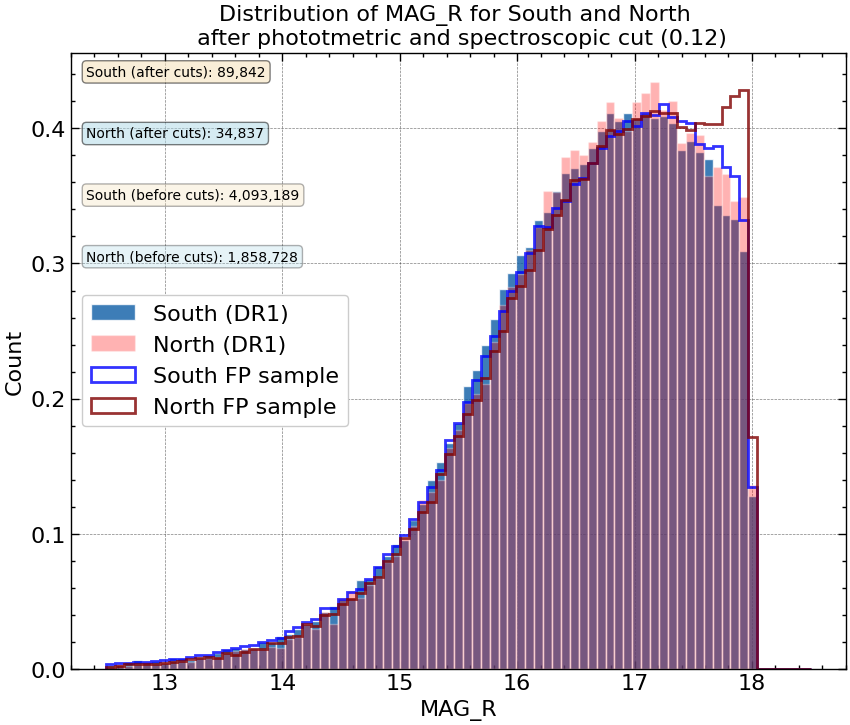

In [ ]:

zspec = 0.12
legacy_south_phot_spec_masked = legacy_south_phot_masked[apply_cuts_spec(legacy_south_phot_masked,zspec)]
legacy_north_phot_spec_masked = legacy_north_phot_masked[apply_cuts_spec(legacy_north_phot_masked,zspec)]
legacy_south_spec_masked = legacy_south[apply_cuts_spec(legacy_south,zspec)]
legacy_north_spec_masked = legacy_north[apply_cuts_spec(legacy_north,zspec)]

legacy_south_phot_masked =legacy_south[apply_cuts_phot(legacy_south)]    
bins = np.linspace(12.5,18.5,80)
plt.figure(figsize=(10,8))
plt.hist(legacy_south_phot_spec_masked['MAG_R'],bins = bins, alpha=0.8, label='South (DR1)',edgecolor='w',density=True)
plt.hist(legacy_north_phot_spec_masked['MAG_R'],bins = bins, alpha=0.3, label='North (DR1)',edgecolor='w',density=True,color='r')  
# Add text boxes with number of elements before and after cuts
plt.text(0.02, 0.98, f'South (after cuts): {len(legacy_south_phot_spec_masked):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(0.02, 0.88, f'North (after cuts): {len(legacy_north_phot_spec_masked):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
plt.text(0.02, 0.78, f'South (before cuts): {len(legacy_south):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
plt.text(0.02, 0.68, f'North (before cuts): {len(legacy_north):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))




plt.hist(data_south['MAG_R'],bins = bins, alpha=0.8, label='South FP sample',density=True,histtype='step',lw=2,color='b')
plt.hist(data_north['MAG_R'],bins = bins, alpha=0.8, label='North FP sample',histtype='step',lw=2,density=True,color='maroon')

plt.xlabel('MAG_R')
plt.ylabel('Count')
plt.title(f'Distribution of MAG_R for South and North \n after phototmetric and spectroscopic cut ({zspec})')
plt.legend()
plt.show()

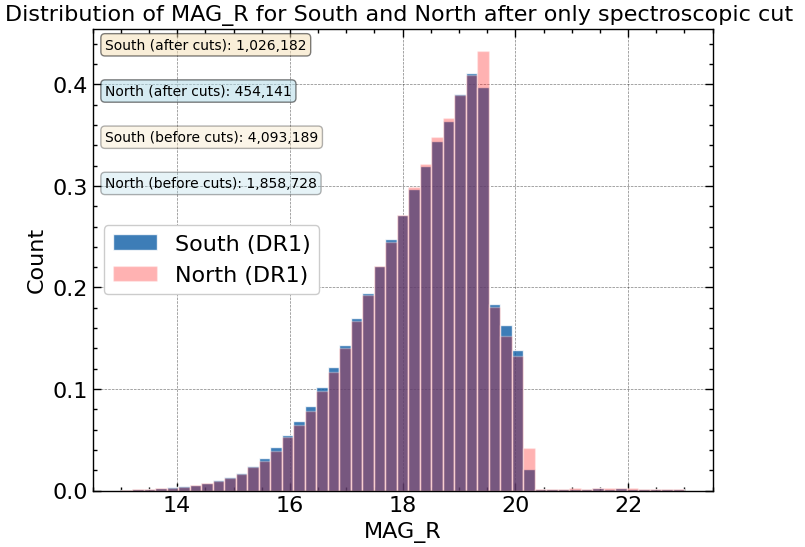

In [ ]:
legacy_south_phot_masked =legacy_south[apply_cuts_phot(legacy_south)]    
bins = np.linspace(13,23,50)
plt.hist(legacy_south_spec_masked['MAG_R'],bins = bins, alpha=0.8, label='South (DR1)',edgecolor='w',density=True)
plt.hist(legacy_north_spec_masked['MAG_R'],bins = bins, alpha=0.3, label='North (DR1)',edgecolor='w',density=True,color='r')  
# Add text boxes with number of elements before and after cuts
plt.text(0.02, 0.98, f'South (after cuts): {len(legacy_south_spec_masked):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(0.02, 0.88, f'North (after cuts): {len(legacy_north_spec_masked):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
plt.text(0.02, 0.78, f'South (before cuts): {len(legacy_south):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
plt.text(0.02, 0.68, f'North (before cuts): {len(legacy_north):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
plt.xlabel('MAG_R')
plt.ylabel('Count')
plt.title('Distribution of MAG_R for South and North after only spectroscopic cut ')
plt.legend()
plt.show()

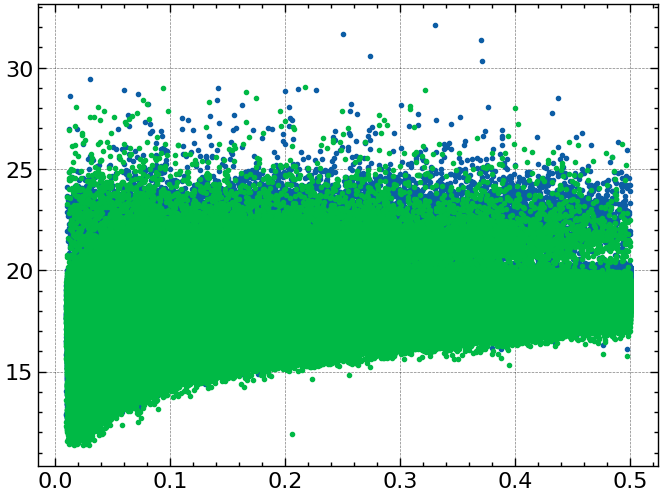

In [140]:
plt.plot(legacy_south['Z_DR1'],legacy_south['MAG_R'],'.')
plt.plot(legacy_south['Z_DR1'],legacy_south['MAG_Z'],'.')

In [ ]:
legacy_south_phot_masked =legacy_south[apply_cuts_phot(legacy_south)]    
bins = np.linspace(12.5,18.5,80)
plt.figure(figsize=(10,8))
plt.hist(legacy_south_phot_spec_masked['MAG_R'],bins = bins, alpha=0.8, label='South (DR1)',edgecolor='w',density=True)
plt.hist(legacy_north_phot_spec_masked['MAG_R'],bins = bins, alpha=0.3, label='North (DR1)',edgecolor='w',density=True,color='r')  
# Add text boxes with number of elements before and after cuts
plt.text(0.02, 0.98, f'South (after cuts): {len(legacy_south_phot_spec_masked):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(0.02, 0.88, f'North (after cuts): {len(legacy_north_phot_spec_masked):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
plt.text(0.02, 0.78, f'South (before cuts): {len(legacy_south):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
plt.text(0.02, 0.68, f'North (before cuts): {len(legacy_north):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))




plt.hist(data_south['MAG_R'],bins = bins, alpha=0.8, label='South (DR1) FP sample',density=True,histtype='step',lw=2,color='b')
plt.hist(data_north['MAG_R'],bins = bins, alpha=0.8, label='North (DR1) FP sample',histtype='step',lw=2,density=True,color='maroon')

plt.xlabel('MAG_R')
plt.ylabel('Count')
plt.title('Distribution of MAG_R for South and North \n after phototmetric and spectroscopic cut (0.15)')
plt.legend()
plt.show()

In [23]:
Number_density_north = len(data_north) / area_north
Number_density_south = len(data_south) / area_south

NameError: name 'data_north' is not defined

In [14]:
len(data_north), len(data_south)

(143843, 339404)

In [21]:
np.sqrt(143843)/ area_north

0.073397847020976

In [ ]:
import numpy as np
np.sqrt(339404)/ area_south

0.047700535681951546

In [18]:
area_north

5167.268694301026

In [17]:
area_south

12213.36178322328

In [22]:
Number_density_north, Number_density_south

NameError: name 'Number_density_north' is not defined